In [7]:
import numpy as np
from utils import OperonArgs
from os.path import join as pjoin
import pandas as pd
import re
import matplotlib.pyplot as plt
import os


Reading from configuration file: conf/iob_0.ini

Splitting data into training, validation, and test sets...
	File: ../data/iob_codes_plus_Acurve_with_ID_LOS.txt
   galaxy_id   los      IOB1      IOB2      IOB3      IOB4      IOB5  \
0   543994.0  10.0 -0.017989 -0.015737 -0.004359  0.002963  0.001226   
1   550643.0  28.0 -0.000106 -0.019296 -0.001042 -0.004605  0.000519   
2   262462.0  17.0 -0.010595 -0.008708  0.006183 -0.002913 -0.006570   
3   198415.0  45.0 -0.027235 -0.001891 -0.008545  0.007224  0.000238   
4   252707.0  48.0  0.056154  0.011966  0.005690  0.014286 -0.011661   

       IOB6      IOB7      IOB8  ...   A_6368A   A_6669A   A_6985A   A_7316A  \
0  0.003877  0.004677  0.000749  ...  0.734766  0.661997  0.610488  0.559659   
1  0.004571  0.004474  0.000670  ...  0.772392  0.716915  0.670423  0.633827   
2  0.007782  0.000963 -0.000877  ...  0.859528  0.818281  0.786897  0.752426   
3  0.004885  0.003701  0.000114  ...  0.771195  0.711688  0.667472  0.622892   
4  0.

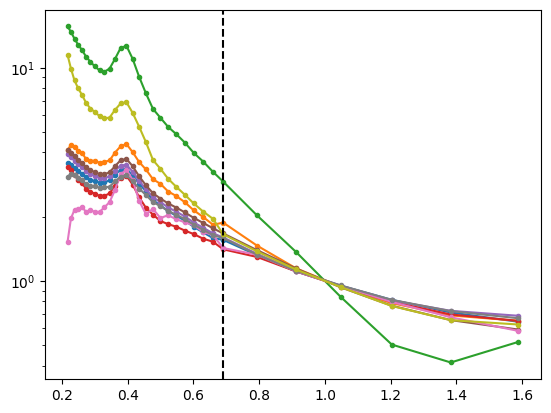

In [24]:
ini_file = 'conf/iob_0.ini'

args = OperonArgs(ini_file)

print('\nSplitting data into training, validation, and test sets...')
print('\tFile:', args.input_file)

# Read all galaxy data
data = pd.read_csv(args.input_file, sep='\t',)
print(data.head())

# Get attenuation column names
if f'logA_{int(args.lambda_V*1e4)}A' in data.keys():
    attenuation_cols = [col for col in data.columns if re.match(r'logA_\d+A', col)]
    if not np.all(data[f'logA_{int(args.lambda_V*1e4)}A'] == 0):
        print('\tWarning: logA_V column is not all zeros: normalising data')
        for col in attenuation_cols:
            data[col] = data[col] - data[f'logA_{int(args.lambda_V*1e4)}A']
        assert np.all(data[f'logA_{int(args.lambda_V*1e4)}A'] == 0), "Normalisation failed"
elif f'A_{int(args.lambda_V*1e4)}A' in data.keys():
    attenuation_cols = [col for col in data.columns if re.match(r'A_\d+A', col)]
    if not np.all(data[f'A_{int(args.lambda_V*1e4)}A'] == 1):
        print('\tWarning: A_V column is not all ones: normalising data')
        for col in attenuation_cols:
            data[col] = data[col] / data[f'A_{int(args.lambda_V*1e4)}A']
        assert np.all(data[f'A_{int(args.lambda_V*1e4)}A'] == 1), "Normalisation failed"
else:
    raise ValueError("Column with lambda_V not found in input file")

# Extract the wavelength in angstroms
# Mask these to range [lam_min, lam_max]
lam_arr = np.array([int(re.search(r'_(\d+)A', col).group(1)) / 1e4 for col in attenuation_cols])
sort_idx = np.argsort(lam_arr)
lam_arr = lam_arr[sort_idx]
mask = (lam_arr < args.lam_max) & (lam_arr > args.lam_min)
lam_arr = lam_arr[mask]
attenuation_cols = [attenuation_cols[i] for i in sort_idx if mask[i]]
print('\tWavelengths:', lam_arr)
lam_arr = lam_arr / args.lambda_V

# Subsample the wavelengths
lambda_trans = 0.3827 / args.lambda_V
f = 3
mask_below = lam_arr < lambda_trans
idx_above = np.nonzero(lam_arr >= lambda_trans)[0]
# Subsample: keep every f-th index above threshold
mask_above = np.zeros_like(mask_below)
mask_above[idx_above[::f]] = True
mask = mask_below | mask_above
lam_arr = lam_arr[mask]
attenuation_cols = [attenuation_cols[i] for i in range(len(attenuation_cols)) if mask[i]]
print('\tSubsampled wavelengths:', lam_arr)
print(mask)


# Get all galaxy ids
galaxy_ids = data['galaxy_id'].unique()
print('\tNumber of unique galaxies:', len(galaxy_ids), 'of', len(data), 'attenuation curves')

# Estimate number of unique IDs needed
ntrain = int(args.ntrain / (args.ntrain + args.nval + args.ntest) * len(galaxy_ids))
nval= int(args.nval / (args.ntrain + args.nval + args.ntest) * len(galaxy_ids))
ntest = len(galaxy_ids) - nval - ntrain
print(f'\tNumber of galaxies for training: {ntrain}, validation: {nval}, test: {ntest}')

# Shuffle the galaxy ids and split into training, validation, and test sets
np.random.seed(args.seed)
np.random.shuffle(galaxy_ids)
train_ids = galaxy_ids[:ntrain]
val_ids = galaxy_ids[ntrain:ntrain+nval]
test_ids = galaxy_ids[ntrain+nval:ntrain+nval+ntest]

# Split data
m = np.isin(data['galaxy_id'], train_ids)
train_data = data[m]
m = np.isin(data['galaxy_id'], val_ids)
val_data = data[m]
m = np.isin(data['galaxy_id'], test_ids)
test_data = data[m]

print('\tOriginal training data shape:', train_data.shape)
print('\tOriginal validation data shape:', val_data.shape)
print('\tOriginal test data shape:', test_data.shape)

# Each galaxy can have more than one los, so we have too many points now
# We again shuffle the data and reduce the number of objects
train_data = train_data.iloc[np.random.permutation(train_data.shape[0])[:args.ntrain],:]
val_data = val_data.iloc[np.random.permutation(val_data.shape[0])[:args.nval], :]
test_data = test_data.iloc[np.random.permutation(test_data.shape[0])[:args.ntest], :]

print('\tNumber of training curves:', train_data.shape[0])
print('\tNumber of validation curves:', val_data.shape[0])
print('\tNumber of test curves:', test_data.shape[0])

# Get cols beginning with in_param and the rest is an integer
in_cols = [col for col in data.columns if col.startswith(args.in_param.upper()) and col[len(args.in_param):].isdigit()]
in_cols.sort()
print(f'\tNumber of input parameters found: {len(in_cols)}')
in_cols = in_cols[:args.npar]
print(f'\tNumber of inputparameters used: {len(in_cols)}')

# Make output directory
dirname = pjoin(args.data_dir, f'{args.in_param}_data_{args.version_num}')
os.makedirs(dirname, exist_ok=True)

for name, data_set in zip(['train', 'val', 'test'], [train_data, val_data, test_data]):
    ngal = len(data_set)
    nlam = len(lam_arr)
    properties = data_set[in_cols].values
    # props_repeated = np.repeat(properties, nlam, axis=0)
    # wavelengths_tiled = np.tile(lam_arr, ngal).reshape(-1, 1)
    # curves_flat = data_set[attenuation_cols].values.reshape(-1, 1)
    curves = data_set[attenuation_cols].values
    print(curves.shape)
    for i in range(3):
        plt.plot(lam_arr, curves[i,:], '.-')
plt.yscale('log')


# [0.1203 0.126  0.132  0.1382 0.1448 0.1516 0.1588 0.1663 0.1742 0.1825
#  0.1911 0.2002 0.2097 0.2196 0.23   0.2409 0.2523 0.2643 0.2768 0.2899
#  0.3036 0.318  0.3331 0.3489 0.3654 0.3827 0.4008 0.4198 0.4397 0.4605
#  0.4824 0.5052 0.5291 0.5542 0.5805 0.608  0.6368 0.6669 0.6985 0.7316
#  0.7663 0.8026 0.8406 0.8804 0.9221 0.9658]
plt.axvline(0.3827 / args.lambda_V, color='k', ls='--')
print(0.3827 / args.lambda_V)
m = lam_arr < 0.3827 / args.lambda_V
print(m.sum(), len(m))

33 46


KeyError: 0

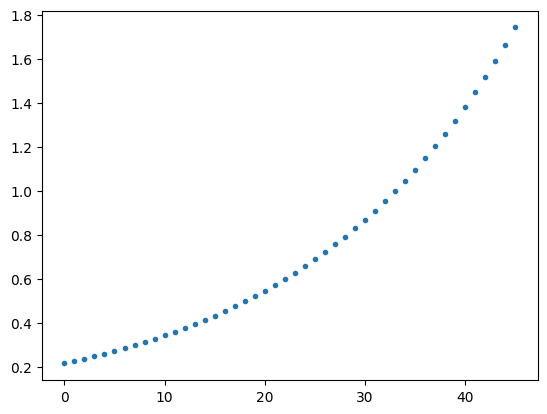

In [ ]:
plt.plot(lam_arr, '.')
m = lam_arr < 1
print(m.sum(), len(m))

# Get